yes
doping =  0.3548 T =  0.0
0.4580414295196533


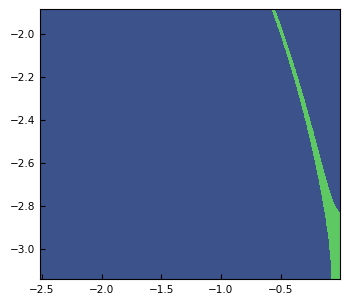

<Figure size 800x800 with 0 Axes>

In [14]:
#pseudo gap in Fermi arc model
import matplotlib.pyplot as plt
import numpy as np
import time

plt.style.use("publication.mplstyle")
fig, axs = plt.subplots(1, figsize=(3.386, 2.093*1.4))

kB = 1.0
t = 1.0

t1 = -0.2
t2 = 0.1

Q = [np.pi, np.pi]

def band(kx, ky):
    return -2.0*t*(np.cos(kx) + np.cos(ky)) - 4.0*t1*np.cos(kx)*np.cos(ky) - 2*t2*(np.cos(2*kx) + np.cos(2*ky))

def band_Q(kx, ky):
    return -2.0*t*(np.cos(kx+Q[0]) + np.cos(ky+Q[1])) - 4.0*t1*np.cos(kx+Q[0])*np.cos(ky+Q[1]) - 2*t2*(np.cos(2*(kx+Q[0])) + np.cos(2*(ky+Q[1])))

def occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T):
    epsilon_minus_mu = epsilon - mu
    epsilon_Q_minus_mu = epsilon_Q - mu
    if T < 1e-8:
        T = 1e-8
    beta = 1.0/T
    E_1 = -beta*epsilon_Q_minus_mu
    E_2 = -beta*(epsilon_minus_mu + epsilon_Q_minus_mu + U)
    E_3 = -beta*epsilon_minus_mu
    E_0 = np.full_like(E_1, 0)
    E_max = np.maximum.reduce([E_0, E_1, E_2, E_3])
    numerator = np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    denominator = np.exp(E_0 - E_max) + np.exp(E_3 - E_max) + np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    return numerator/denominator

def average_occupation(mu, T, U, KX, KY, N):
    epsilon = band(KX, KY)
    epsilon_Q = band_Q(KX, KY)
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    return 2.0*np.sum(n_k) / N

def lorentzian(x, delta=0.005):
    return delta / (np.pi * (x * x + delta * delta))

def spectrum(kx, ky, omega, epsilon, epsilon_Q, mu, U, T):
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    spectrum = (1 - n_k)*lorentzian(omega - (band(kx, ky) - mu)) + n_k*lorentzian(omega - (band(kx, ky) - mu) - U)
    return spectrum

U = 2.0
T = 0.0
mu = -1.205

Nk = 1000
kx_list = np.linspace(0.8*-np.pi, 0, Nk, endpoint=False)
ky_list = np.linspace(-np.pi, -0.6*np.pi, Nk, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk * Nk
start_time = time.time()

spectrum_2d = np.full_like(KX, 0)
epsilon = band(KX, KY)
epsilon_Q = band_Q(KX, KY)
spectrum_2d = spectrum(KX, KY, 0, epsilon, epsilon_Q, mu, U, T)
        
fig = plt.figure(figsize=(8, 8))
threshold = 0.1 * np.max(spectrum_2d)
binary_spectrum = (spectrum_2d > threshold).astype(float)

axs.contourf(KX, KY, binary_spectrum, cmap="viridis", levels=[0, 0.5, 1])
plt.show

Nk = 400
kx_list = np.linspace(-np.pi, 0, Nk, endpoint=False)
ky_list = np.linspace(-np.pi, 0, Nk, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk * Nk

if np.any(binary_spectrum[0, :] == 1) or np.any(binary_spectrum[:, -1] == 1):
    print("yes")
    x = 1.0- average_occupation(mu, T, U, KX, KY, N)
    print('doping = ', x, 'T = ', T)
else:
    print('no')
    x = 1.0- average_occupation(mu, T, U, KX, KY, N)
    print('doping = ', x, 'T = ', T)

end_time = time.time()
print(end_time - start_time)

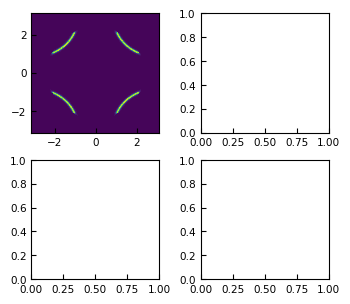

<Figure size 800x800 with 0 Axes>

In [9]:
#Fermi arc model density polt Fig1 PHYSICAL REVIEW LETTERS 133, 166501 (2024) Fermi surface
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.optimize import brentq
import matplotlib.cm as cm
import time

plt.style.use("publication.mplstyle")
fig, axs = plt.subplots(2, 2, figsize=(3.386, 2.093*1.4))

kB = 1.0
t = 1.0

t1 = -0.2
t2 = 0.1

Q = [np.pi, np.pi]

def band(kx, ky):
    return -2.0*t*(np.cos(kx) + np.cos(ky)) - 4.0*t1*np.cos(kx)*np.cos(ky) - 2*t2*(np.cos(2*kx) + np.cos(2*ky))

def band_Q(kx, ky):
    return -2.0*t*(np.cos(kx+Q[0]) + np.cos(ky+Q[1])) - 4.0*t1*np.cos(kx+Q[0])*np.cos(ky+Q[1]) - 2*t2*(np.cos(2*(kx+Q[0])) + np.cos(2*(ky+Q[1])))

def occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T):
    epsilon_minus_mu = epsilon - mu
    epsilon_Q_minus_mu = epsilon_Q - mu
    if T < 1e-8:
        T = 1e-8
    beta = 1.0/T
    E_1 = -beta*epsilon_Q_minus_mu
    E_2 = -beta*(epsilon_minus_mu + epsilon_Q_minus_mu + U)
    E_3 = -beta*epsilon_minus_mu
    E_0 = np.full_like(E_1, 0)
    E_max = np.maximum.reduce([E_0, E_1, E_2, E_3])
    numerator = np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    denominator = np.exp(E_0 - E_max) + np.exp(E_3 - E_max) + np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    return numerator/denominator

def average_occupation(mu, T, U, KX, KY, N):
    epsilon = band(KX, KY)
    epsilon_Q = band_Q(KX, KY)
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    return 2.0*np.sum(n_k) / N

def lorentzian(x, delta=0.04):
    return delta / (np.pi * (x * x + delta * delta))

def spectrum(kx, ky, omega, epsilon, epsilon_Q, mu, U, T):
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    spectrum = (1 - n_k)*lorentzian(omega - (band(kx, ky) - mu)) + n_k*lorentzian(omega - (band(kx, ky) - mu) - U)
    return spectrum

U = 2.0
#T = 0.001713534134609854
#mu = -0.674

T = 0.0
mu = 0.0


Nk = 256
kx_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
ky_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk * Nk

spectrum_2d = np.full_like(KX, 0)
epsilon = band(KX, KY)
epsilon_Q = band_Q(KX, KY)
spectrum_2d = spectrum(KX, KY, 0, epsilon, epsilon_Q, mu, U, T)

fig = plt.figure(figsize=(8, 8))
N_levels = 40
np.save(f'spectrum_K{Nk}_U={U}_mu={mu}', spectrum_2d)
axs[0, 0].contourf(KX, KY, spectrum_2d, cmap="viridis", levels=N_levels)

In [5]:
#pseudo gap in Fermi arc model
import numpy as np
import time

kB = 1.0
t = 1.0

t1 = -0.2
t2 = 0.1

Q = [np.pi, np.pi]

def band(kx, ky):
    return -2.0*t*(np.cos(kx) + np.cos(ky)) - 4.0*t1*np.cos(kx)*np.cos(ky) - 2*t2*(np.cos(2*kx) + np.cos(2*ky))

def band_Q(kx, ky):
    return -2.0*t*(np.cos(kx+Q[0]) + np.cos(ky+Q[1])) - 4.0*t1*np.cos(kx+Q[0])*np.cos(ky+Q[1]) - 2*t2*(np.cos(2*(kx+Q[0])) + np.cos(2*(ky+Q[1])))

def occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T):
    epsilon_minus_mu = epsilon - mu
    epsilon_Q_minus_mu = epsilon_Q - mu
    if T < 1e-8:
        T = 1e-8
    beta = 1.0/T
    E_1 = -beta*epsilon_Q_minus_mu
    E_2 = -beta*(epsilon_minus_mu + epsilon_Q_minus_mu + U)
    E_3 = -beta*epsilon_minus_mu
    E_0 = np.full_like(E_1, 0)
    E_max = np.maximum.reduce([E_0, E_1, E_2, E_3])
    numerator = np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    denominator = np.exp(E_0 - E_max) + np.exp(E_3 - E_max) + np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    return numerator/denominator

def average_occupation(mu, T, U, KX, KY, N):
    epsilon = band(KX, KY)
    epsilon_Q = band_Q(KX, KY)
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    return 2.0*np.sum(n_k) / N

def lorentzian(x, delta=0.005):
    return delta / (np.pi * (x * x + delta * delta))

def spectrum(kx, ky, omega, epsilon, epsilon_Q, mu, U, T):
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    spectrum = (1 - n_k)*lorentzian(omega - (band(kx, ky) - mu)) + n_k*lorentzian(omega - (band(kx, ky) - mu) - U)
    return spectrum

Nk = 1000
kx_list = np.linspace(0.8*-np.pi, 0, Nk, endpoint=False)
ky_list = np.linspace(-np.pi, -0.6*np.pi, Nk, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk * Nk

spectrum_2d = np.full_like(KX, 0)

U = 2.0
T = 0.0

N_mu_list_pseudo = 8
#mu_list_pseudo = np.linspace(-1.19, -0.2, N_mu_list_pseudo)
mu_list_pseudo = [-1.2, -1.04857143, -0.90714286, -0.76571429, -0.62428571, -0.48285714, -0.34142857, -0.2 ]

mu_result = []
T_result = []

start_time = time.time()

for k in range(0, len(mu_list_pseudo)):
    while True:
        mu = mu_list_pseudo[k]
        epsilon = band(KX, KY)
        epsilon_Q = band_Q(KX, KY)
        spectrum_2d = spectrum(KX, KY, 0, epsilon, epsilon_Q, mu, U, T)
        threshold = 0.1 * np.max(spectrum_2d)
        binary_spectrum = (spectrum_2d > threshold).astype(float)
        if np.any(binary_spectrum[0, :] == 1) or np.any(binary_spectrum[:, -1] == 1):
            mu_result.append(mu_list_pseudo[k])
            T_result.append(T)
            print('mu = ', mu, 'T = ', T)
            break   
        T = T + 0.01
        print(T)
        
end_time = time.time()
print(end_time-start_time)

Nk = 400
kx_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
ky_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk * Nk
doping_result = []
for i in range(0, len(mu_result)):
    doping_result.append(1.0 - average_occupation(mu_result[i], T_result[i], U, KX, KY, N))

print(doping_result)
np.save(f'pseudo_U={U}_T_g', T_result)
np.save(f'pseudo_U={U}_doping_g', doping_result)
np.save(f'pseudo_U={U}_mu_g', mu_result)

mu =  -1.2 T =  0.0
0.01
0.02
0.03
0.04
0.05
0.060000000000000005
mu =  -1.04857143 T =  0.060000000000000005
0.07
0.08
0.09
0.09999999999999999
0.10999999999999999
0.11999999999999998
mu =  -0.90714286 T =  0.11999999999999998
0.12999999999999998
0.13999999999999999
0.15
0.16
0.17
0.18000000000000002
mu =  -0.76571429 T =  0.18000000000000002
0.19000000000000003
0.20000000000000004
0.21000000000000005
0.22000000000000006
0.23000000000000007
0.24000000000000007
mu =  -0.62428571 T =  0.24000000000000007
0.25000000000000006
0.26000000000000006
0.2700000000000001
0.2800000000000001
0.2900000000000001
0.3000000000000001
0.3100000000000001
mu =  -0.48285714 T =  0.3100000000000001
0.3200000000000001
0.3300000000000001
0.34000000000000014
0.35000000000000014
0.36000000000000015
mu =  -0.34142857 T =  0.36000000000000015
0.37000000000000016
0.38000000000000017
0.3900000000000002
mu =  -0.2 T =  0.3900000000000002
15.320632219314575
[0.35327916666660497, 0.2708845138007294, 0.2235578084335822

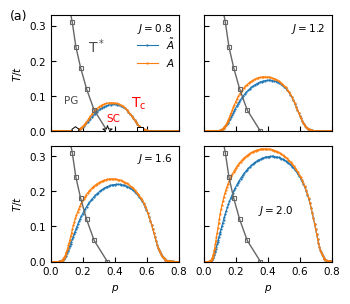

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.optimize import brentq
import time
import matplotlib.pyplot as plt


plt.style.use("publication.mplstyle")
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(3.386, 2.093*1.4))
U = 2.0
g = 0.8

x_final11 = np.load(f'x_U={U}_g={g}.npy')
x_final11_0 = np.load(f'x0_U={U}_g={g}.npy')
Tc_final11 = np.load(f'Tc_U={U}_g={g}.npy')
Tc_final11_0 = np.load(f'Tc0_U={U}_g={g}.npy')
axs[0, 0].plot(x_final11, Tc_final11, 'o-', linewidth=0.8, markersize=0.8, label=r'$\tilde{A}$')
axs[0, 0].plot(x_final11_0, Tc_final11_0, 'o-', linewidth=0.8, markersize=0.8, label=r'$A$')
axs[0, 0].text(
    x=0.95,                     
    y=0.95,                     
    s=f'$J={g}$',               
    transform=axs[0, 0].transAxes, 
    horizontalalignment='right',  
    verticalalignment='top',      
)
axs[0, 0].legend(
    loc='upper left',
    bbox_to_anchor=(0.6, 0.9)
)
#axs[0, 0].legend(loc='upper left')

U = 2.0
g = 1.2
x_final14 = np.load(f'x_U={U}_g={g}.npy')
x_final14_0 = np.load(f'x0_U={U}_g={g}.npy')
Tc_final14 = np.load(f'Tc_U={U}_g={g}.npy')
Tc_final14_0 = np.load(f'Tc0_U={U}_g={g}.npy')
axs[0, 1].plot(x_final14, Tc_final14, 'o-', linewidth=0.8, markersize=0.8, label=f'A')
axs[0, 1].plot(x_final14_0, Tc_final14_0, 'o-', linewidth=0.8, markersize=0.8, label=r'$A_0$')
axs[0, 1].text(
    x=0.95,                     
    y=0.95,                     
    s=f'$J={g}$',               
    transform=axs[0, 1].transAxes, 
    horizontalalignment='right',  
    verticalalignment='top',      
)

U = 2.0
g = 1.6
x_final17 = np.load(f'x_U={U}_g={g}.npy')
x_final17_0 = np.load(f'x0_U={U}_g={g}.npy')
Tc_final17 = np.load(f'Tc_U={U}_g={g}.npy')
Tc_final17_0 = np.load(f'Tc0_U={U}_g={g}.npy')
axs[1, 0].plot(x_final17, Tc_final17, 'o-', linewidth=0.8, markersize=0.8, label=f'A')
axs[1, 0].plot(x_final17_0, Tc_final17_0, 'o-', linewidth=0.8, markersize=0.8, label=r'$A_0$')
axs[1, 0].text(
    x=0.95,                     
    y=0.95,                     
    s=f'$J={g}$',               
    transform=axs[1, 0].transAxes, 
    horizontalalignment='right',  
    verticalalignment='top',      
)

U = 2.0
g = 2.0
x_final20 = np.load(f'x_U={U}_g={g}.npy')
x_final20_0 = np.load(f'x0_U={U}_g={g}.npy')
Tc_final20 = np.load(f'Tc_U={U}_g={g}.npy')
Tc_final20_0 = np.load(f'Tc0_U={U}_g={g}.npy')
axs[1, 1].plot(x_final20, Tc_final20, 'o-', linewidth=0.8, markersize=0.8, label=f'A')
axs[1, 1].plot(x_final20_0, Tc_final20_0, 'o-', linewidth=0.8, markersize=0.8, label=r'$A_0$')
#axs[1, 1].set_title(f'$U={U}, g={g}$', loc='right')
axs[1, 1].text(
    x=0.7,                     
    y=0.5,                     
    s=f'$J={g}$',               
    transform=axs[1, 1].transAxes, 
    horizontalalignment='right',  
    verticalalignment='top',      
)
axs[1, 1].set_xlim(0, 0.8)
axs[1, 1].set_ylim(0, 0.33)

#axs[0, 0].scatter(0.1535385142149972, 0.003, s=30, marker='p', color='tab:cyan', linewidths=0, zorder=2)
#axs[0, 0].scatter(0.38645948958637044, 0.07605844333106182, s=30, marker='p', color='red', linewidths=0, zorder=2)

axs[0, 0].scatter(0.1535385142149972, 0.003, 
                  s=30,            # 增大点的大小，方便观察效果
                  marker='p',       # 五边形
                  facecolors='white',# 填充颜色
                  edgecolors='black',# 边框颜色
                  linewidths=0.7,     # 边框粗细，建议不要太大，否则会遮挡形状
                  zorder=2)
#axs[0, 0].scatter(0.36, 0.003, s=35, marker='p', color='black', linewidths=0, zorder=3, alpha = 0.8)
axs[0, 0].scatter(0.35, 0.003, 
                  s=50,            # 增大点的大小，方便观察效果
                  marker='*',       # 五边形
                  facecolors='white',# 填充颜色
                  edgecolors='black',# 边框颜色
                  linewidths=0.7,     # 边框粗细，建议不要太大，否则会遮挡形状
                  zorder=3)
axs[0, 0].scatter(0.56, 0.003, 
                  s=15,            # 增大点的大小，方便观察效果
                  marker='s',       # 五边形
                  facecolors='white',# 填充颜色
                  edgecolors='black',# 边框颜色
                  linewidths=0.7,     # 边框粗细，建议不要太大，否则会遮挡形状
                  zorder=2)

axs[1, 0].set_xlabel(r'$p$')
axs[1, 1].set_xlabel(r'$p$')
axs[0, 0].set_ylabel(r'$T/t$')
axs[1, 0].set_ylabel(r'$T/t$')
#axs[1, 1].legend()
#plt.show()

T_result = np.load(f'pseudo_U={U}_T_g.npy')
doping_result = np.load(f'pseudo_U={U}_doping_g.npy')

#doping_list = [0.327575684,0.254544598,0.229198856,0.180865022,0.167715078]
#T_list = [0,0.13,0.21,0.3,0.38]
axs[0, 0].plot(doping_result, T_result, '-', linewidth=1, markersize=2.5, marker='s', markerfacecolor='none',color='0.4')
axs[0, 1].plot(doping_result, T_result, '-', linewidth=1, markersize=2.5, marker='s', markerfacecolor='none',color='0.4')
axs[1, 0].plot(doping_result, T_result, '-', linewidth=1, markersize=2.5, marker='s', markerfacecolor='none',color='0.4')
axs[1, 1].plot(doping_result, T_result, '-', linewidth=1, markersize=2.5, marker='s', markerfacecolor='none',color='0.4')
axs[0, 0].text(0.23, 0.225, r'T$^*$', fontsize=10, color='0.3')
axs[0, 0].text(0.08, 0.08, r'PG', fontsize=7.5, color='0.3')
axs[0, 0].text(0.5, 0.07, r'T$_\text{c}$', fontsize=10, color='r')
axs[0, 0].text(0.35, 0.027, r'SC', fontsize=7.5, color='r')

axs[0, 0].text(-0.25, 1.05, '(a)', transform=axs[0,0].transAxes, 
        fontsize=9, va='top', ha='center')

axs[0, 0].set_xticks([0.0, 0.2, 0.4, 0.6, 0.8])
axs[1, 0].set_xticks([0.0, 0.2, 0.4, 0.6, 0.8])
axs[0, 1].set_xticks([0.0, 0.2, 0.4, 0.6, 0.8])
axs[1, 1].set_xticks([0.0, 0.2, 0.4, 0.6, 0.8])

#plt.savefig(f'g')


C:\Users\fishb\AppData\Local\Temp\ipykernel_16820\3287739306.py:18: RuntimeWarning: invalid value encountered in divide
  T_difference11 = (Tc_final11-Tc_final11_0)/Tc_final11
C:\Users\fishb\AppData\Local\Temp\ipykernel_16820\3287739306.py:28: RuntimeWarning: invalid value encountered in divide
  T_difference13 = (Tc_final13-Tc_final13_0)/Tc_final13
C:\Users\fishb\AppData\Local\Temp\ipykernel_16820\3287739306.py:38: RuntimeWarning: invalid value encountered in divide
  T_difference15 = (Tc_final15-Tc_final15_0)/Tc_final15
C:\Users\fishb\AppData\Local\Temp\ipykernel_16820\3287739306.py:47: RuntimeWarning: invalid value encountered in divide
  T_difference18 = (Tc_final18-Tc_final18_0)/Tc_final18


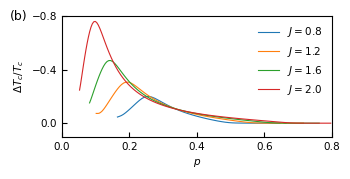

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.optimize import brentq
import time

plt.figure(figsize=(3.386, 2.093*0.8))
import matplotlib.pyplot as plt
plt.style.use("publication.mplstyle")

U = 2.0
g = 0.8

x_final11 = np.load(f'x_U={U}_g={g}.npy')
x_final11_0 = np.load(f'x0_U={U}_g={g}.npy')
Tc_final11 = np.load(f'Tc_U={U}_g={g}.npy')
Tc_final11_0 = np.load(f'Tc0_U={U}_g={g}.npy')
T_difference11 = (Tc_final11-Tc_final11_0)/Tc_final11
plt.plot(x_final11[x_final11 >= 0.16], T_difference11[x_final11 >= 0.16], label=f'$J={g}$')

U = 2.0
g = 1.2
x_final13 = np.load(f'x_U={U}_g={g}.npy')
x_final13_0 = np.load(f'x0_U={U}_g={g}.npy')
Tc_final13 = np.load(f'Tc_U={U}_g={g}.npy')
Tc_final13_0 = np.load(f'Tc0_U={U}_g={g}.npy')

T_difference13 = (Tc_final13-Tc_final13_0)/Tc_final13
plt.plot(x_final13[x_final13 >= 0.1], T_difference13[x_final13 >= 0.1], label=f'$J={g}$')

U = 2.0
g = 1.6
x_final15 = np.load(f'x_U={U}_g={g}.npy')
x_final15_0 = np.load(f'x0_U={U}_g={g}.npy')
Tc_final15 = np.load(f'Tc_U={U}_g={g}.npy')
Tc_final15_0 = np.load(f'Tc0_U={U}_g={g}.npy')

T_difference15 = (Tc_final15-Tc_final15_0)/Tc_final15
plt.plot(x_final15[x_final15 >= 0.08], T_difference15[x_final15 >= 0.08], label=f'$J={g}$')

U = 2.0
g = 2.0
x_final18 = np.load(f'x_U={U}_g={g}.npy')
x_final18_0 = np.load(f'x0_U={U}_g={g}.npy')
Tc_final18 = np.load(f'Tc_U={U}_g={g}.npy')
Tc_final18_0 = np.load(f'Tc0_U={U}_g={g}.npy')
T_difference18 = (Tc_final18-Tc_final18_0)/Tc_final18
plt.plot(x_final18[x_final18 >= 0.05], T_difference18[x_final18 >= 0.05], label=f'$J={g}$')
plt.xlabel(r'$p$')
plt.ylabel(r'$\Delta T_c/T_c$')

ax = plt.gca()
# transform=ax.transAxes 确保坐标 (0,1) 永远指向左上角
ax.text(-0.16, 1.05, '(b)', transform=ax.transAxes, 
        fontsize=9, va='top', ha='center')

plt.legend()
plt.xlim(0, 0.8)
plt.ylim(0.1,-0.8)
plt.xticks([0.0, 0.2, 0.4, 0.6, 0.8])
plt.yticks([0.0, -0.4, -0.8])
#plt.savefig(f'g_difference')
plt.show()